<img src="data6.png" style="width: 15%; float: right; padding: 1%; margin-right: 2%;"/>

# Lab 5 – Introduction to Visualization Methods

NEW INTRO

In [80]:
# Run this cell to load all required Python libraries
import numpy as np
from datascience import *

import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("fivethirtyeight")
%matplotlib inline

## [Tutorial] Where `barh` fails

The `barh` method works well on categorical variables, but what if we have a **numerical** variable that we want to see the distribution of? 

Consider the Data Scientist salary data we've been using from INSERT LINK Kaggle. In this lab, we'll use the cleaned dataset, where Education levels are one of four categories: High School, Bachelor's Degree, Master's Degree, and PhD.

In [54]:
salary = Table.read_table("salary.csv")
salary.show(5)

Age,Gender,Education Level,Job Title,Years of Experience,Salary,Unnamed: 6
32,Male,Bachelor's Degree,Software Engineer,5,90000,False
28,Female,Master's Degree,Data Analyst,3,65000,False
45,Male,PhD,Senior Manager,15,150000,False
36,Female,Bachelor's Degree,Sales Associate,7,60000,False
52,Male,Master's Degree,Director,20,200000,False


Let's see what happens if we try to use `barh` on a numerical variable (`"Years of Experience"`) instead of a categorical variable:

As you can see, this bar plot is not particularly helpful. There are many categories that seem to not have any corresponding bar. Yet, that isn't the case! Seeing the breakdown of `"Years of Experience"` does not provide us with any useful information, and it is also difficult to read or understand. Instead, for numerical variables, we have another visualization method that helps us visualize a numerical variable's distribution: **histograms**.

---
### **The [hist](http://data8.org/datascience/_autosummary/datascience.tables.Table.hist.html#datascience.tables.Table.hist) method**

The `hist` method allows us to see the distribution of a numerical variable. `hist` takes in 1 mandatory argument and has several optional arguments (feel free to look through the documentation and explore these optional arguments as before). **Remember: categorical variables should be visualized using `barh`, and numerical variables should be visualized using `hist`.**

Let's take a look at the distribution of salaries among people to see how the `hist` method helps visualize numerical variables. We'll use the `salary` table to create this histogram.

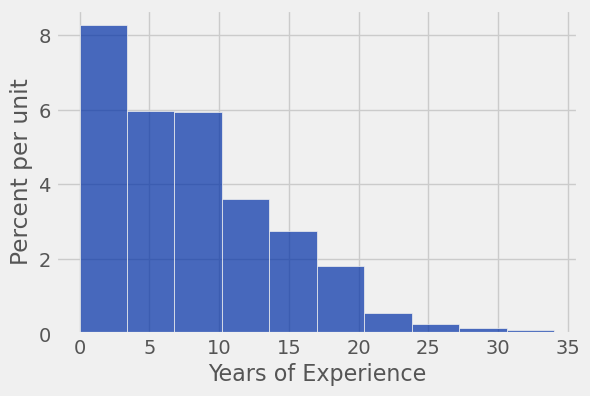

In [56]:
salary.hist("Years of Experience")

The above histogram represents the area of each bin as the percentage of values in that bin. We could optionally set `density=False` to plot our distribution using counts per bin:

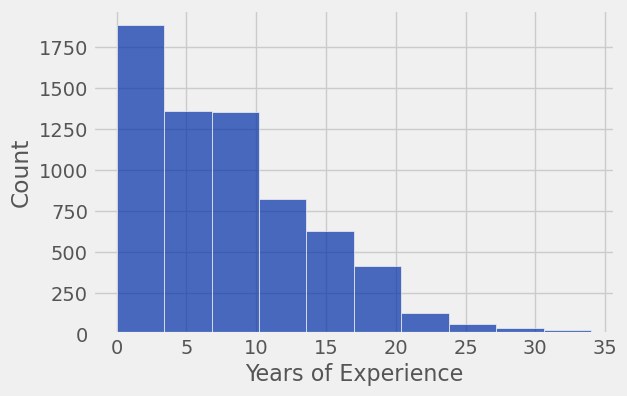

In [57]:
# just run this cell
salary.hist("Years of Experience", density=False)

Later in this lab, we will explore the tradeoffs of plotting counts vs. percentages of bins. For now, let us consider what the number and sizes of bins tell us.

## Question 1

Consider the below code, which produces a histogram representing the **distribution of employee salaries**:

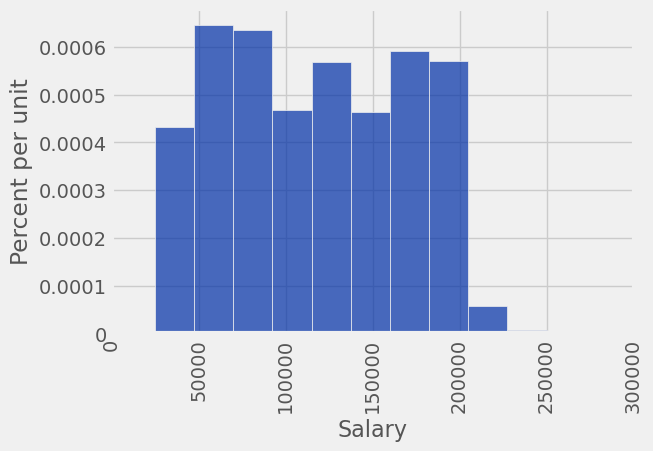

In [58]:
salary.hist("Salary")

Changing the number of bins can change the appearance of a histogram, which can either reveal or hide patterns within the data.

By default, the `hist` Table method automatically chooses ten equally-spaced bins for the data.  The `hist` Table method has an optional `bins` argument to customize bins. It takes two possible types of values:
* **int**: Plot n equally-spaced bins.
* **array**: To specify n bins, provide an (n+1)-length array. The first n array elements specify the left endpoints of each bin, in order. The last array element specifies the right endpoint of the last bin.

Let's explore adjusting the number of bins first.


---

## Question 1(a)

Set the number of bins to 20 and plot a new histogram. How does the distribution of the datapoints look? Briefly answer whether you are able to interpret the patterns and details within the data.

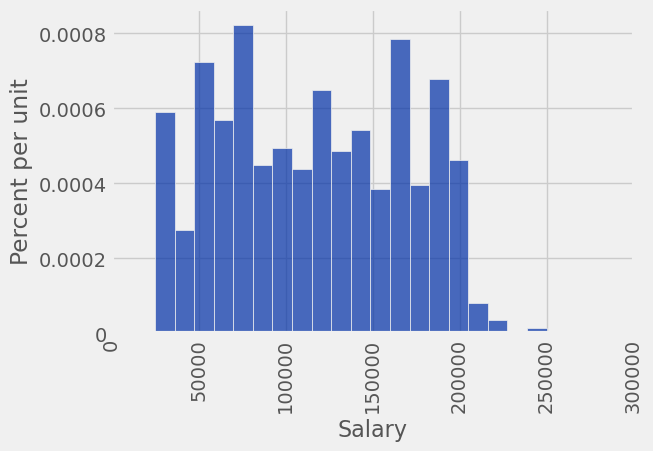

In [70]:
salary.hist("Salary", bins=20) # SOLUTION NO PROMPT


---

## Question 1(b)

Next, consider setting the number of bins to 3 or 2000. How does the distribution of the datapoints look? Briefly answer whether you are able to interpret the patterns and details within the data. We've provided a code cell in case it is useful.

In [ ]:
# YOUR CODE HERE


---

## Question 1(c)

Based on the results of manipulating the bins in the previous parts, which bin selection produced the most interpretable histogram: 3, 10, 20, or 2000? Why?

**answer here**

---

## Question 2: Bachelor's Degree vs. PhD Degere

Next, we'll explore a functionality of histograms that allows us to compare the salaries of Bachelor's degree holders vs. those of PhD holders. We can use `hist` on a `Table` with the rows for just these two education levels and use the optional `group` argument.

*Note*: You'll see how `are.contained_in` works with the `where` method in the next lab. For now, think of it as finding any rows corresponding to *either* `"Bachelor's Degree"` or `"PhD Degree"`.

In [64]:
# Just run this cell to create the `bachelor_master` table
bachelor_phd = salary.where("Education Level", are.contained_in(["Bachelor's Degree", "PhD"]))
bachelor_phd.show(5)

Age,Gender,Education Level,Job Title,Years of Experience,Salary,Unnamed: 6
32,Male,Bachelor's Degree,Software Engineer,5,90000,False
45,Male,PhD,Senior Manager,15,150000,False
36,Female,Bachelor's Degree,Sales Associate,7,60000,False
29,Male,Bachelor's Degree,Marketing Analyst,2,55000,False
31,Male,Bachelor's Degree,Sales Manager,4,80000,False


### Question 2(a)
Now that we've created our `bachelor_phd` table, fill in the following code cell to produce a histogram representing the ***distribution of salary*** for *both* people with a Bachelor's degree and people with a PhD.

*Hint*: Take a look at the optional `group` argument in the documentation.

*Note*: Set the optional `bins` argument of the `hist` method to `my_bins`. We've provided this variable for you.

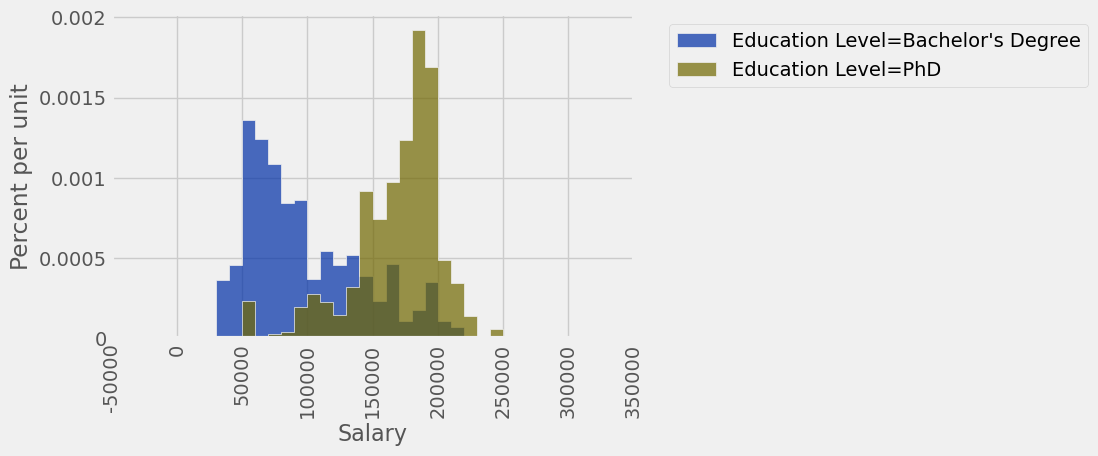

In [67]:
my_bins = np.arange(0, 300000, 10000)
bachelor_phd.hist("Salary", group = "Education Level", bins = my_bins)

When analyzing histograms, data scientists often have to describe their distribution (shape) of the histogram, using some of the following terms:


*   **Center:** A value that summarizes the midpoint of the datapoints' distribution.
*   **Spread:** How much the datapoints vary, i.e., the width of the distribution.
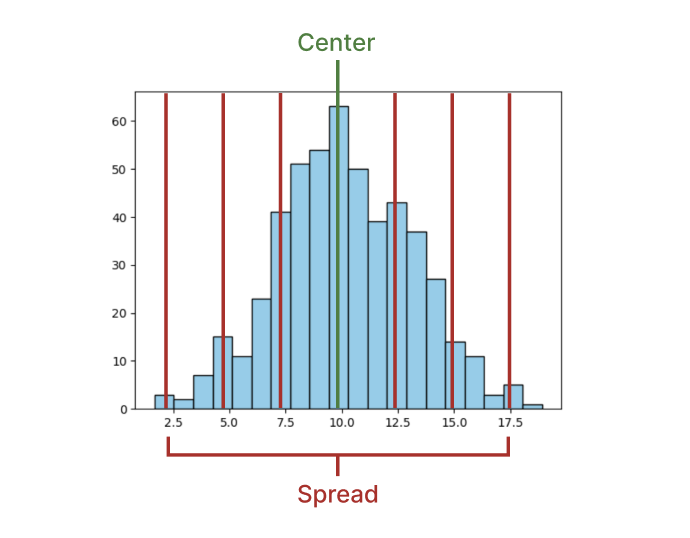

*   **Skew:** Which way the data "leans". A right skew means that more of the data is on the left and the tail of the data is on the right. A left skew means that more of the data is on the right and the tail of the data is on the left.
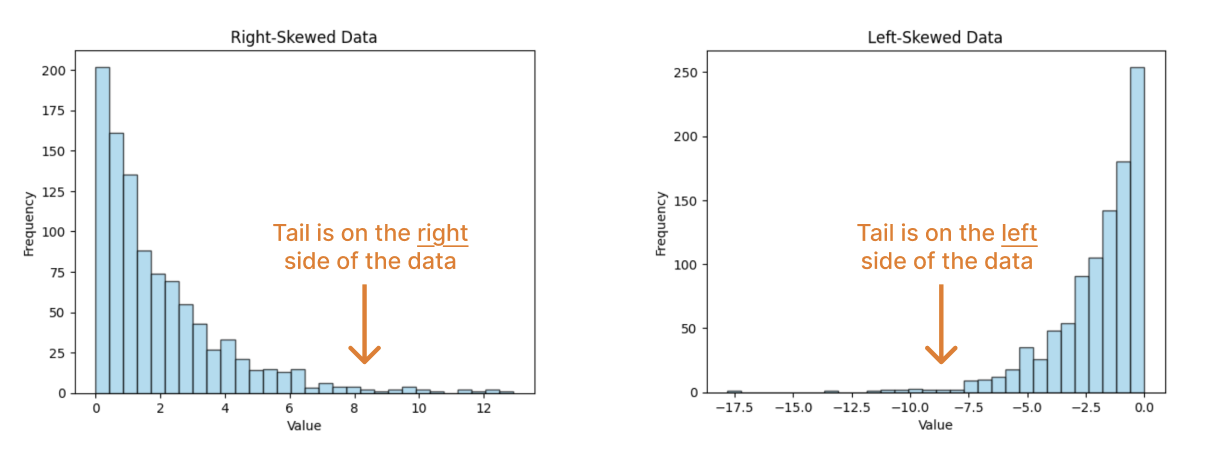

---

## Question 2b

What skew does the Bachelor degree salary distribution have? Assign `skew_bachelor` to the string "left" or "right".

In [71]:
skew_bachelor = "right"

---

## Question 2c

Let's consider how summary statistics might interplay with this notion of skew.

Fill in the below code to compute the means and medians of both the Bachelor's degree salary distribution and the PhD salary distribution. The `bachelor` and `phd` arrays have been created for your convenience.

TODO NOTE: probably need to include `np.median` in reference

In [76]:
bachelor = bachelor_phd.where("Education Level", "Bachelor's Degree").column("Salary")
phd = bachelor_phd.where("Education Level", "PhD").column("Salary")

mean_bachelor = np.mean(bachelor) # SOLUTION
median_bachelor = np.median(bachelor) # SOLUTION
print(f"Bachelor's degree:\tmean: {mean_bachelor}\tmedian: {median_bachelor}")

mean_phd = np.mean(phd) # SOLUTION
median_phd = np.median(phd) # SOLUTION
print(f"PhD:\t\t\tmean: {mean_phd}\tmedian: {median_phd}")

Bachelor's degree:	mean: 95176.96056991385	median: 80000.0
PhD:			mean: 165772.125	median: 170000.0


TODO: autograder tests on `mean_bachelor` `median_bachelor` `mean_phd` and `median_phd`

## Question 2d

Based on the numbers above, complete the below statement:

    A right skew (i.e., tail on right) implies that the mean is _______ the median.

Fill in the blank by assigning `q_2d` to `"less than"`, `"equal to"`, or `"greater than"`.

In [77]:
q_2d = "greater than" # SOLUTION

## [Tutorial] Counts or Density?

It should be noted that there are many more individuals with a Bachelor's degree than a PhD:

In [68]:
bachelor_phd.group("Education Level")

Education Level,count
Bachelor's Degree,3018
PhD,1368


This difference in sample sizes can impact our analysis.

<div class="alert alert-warning">
Here is where we could have arrived at some unreliable conclusions: for all the histograms in this lab so far, we've been taking a look at the density plots of these histograms, in which the y-axis is displayed in percent per unit rather than simply count. Let's take a look at what the plot could have looked like, if we were choosing to make count plots for our histograms instead:
</div>

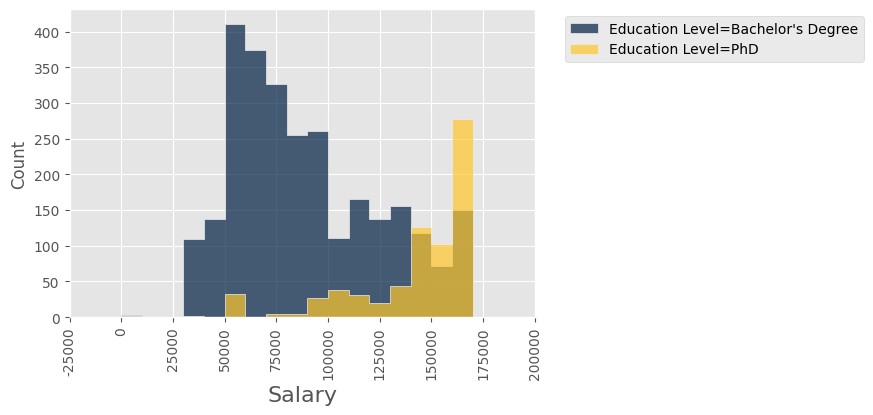

In [27]:
my_bins = np.arange(0, 180000, 10000)
bachelor_phd.hist("Salary", density = False, group = "Education Level", bins = my_bins)

<div class="alert alert-warning">
When we make use of the <code>density = False</code> argument, we see that the y-axis plots the **counts of individuals** instead. As we discovered earlier, the sample sizes of the bachelor's holders vs. PhD holders in this dataset are quite different, and so it's difficult to draw any reliable conclusions from the plot above. When using histograms to visualize data in the future, pay attention to whether a density distribution or a count distribution makes the most sense and is the most reliable for drawing conclusions!
</div>

---

## Question 3: Box plots and percentiles

Finally, let's compare the salaries of different degree holders using box plots.

Note: In this class, you are expected to be able to interpret box plots. We will not expect you to write code to plot box plots.

Boxplot of x values in mystery datasets


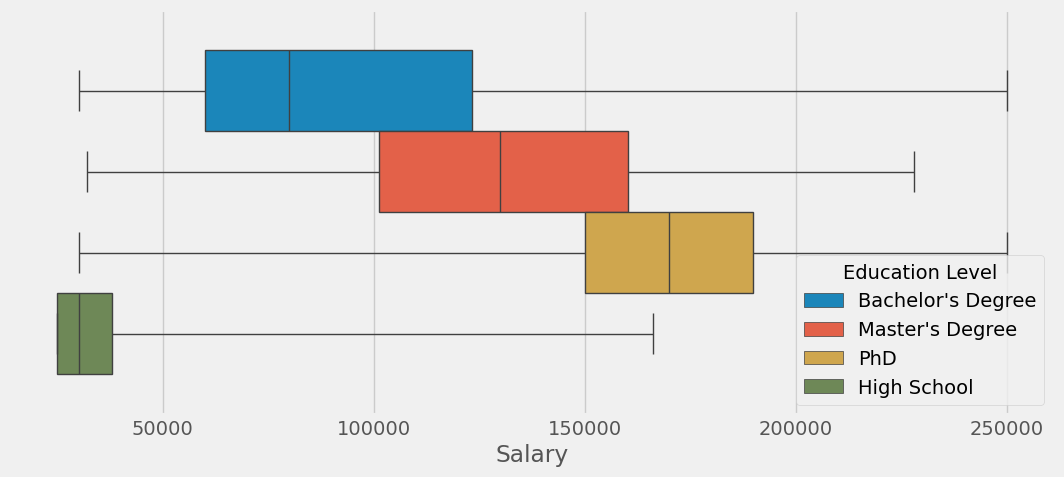

In [83]:
# just run this cell
plt.figure(figsize=(12, 5))
sns.boxplot(data=salary, x="Salary", hue="Education Level", whis=(0, 100))
print("Boxplot of x values in mystery datasets")

---

## Question 3a

Which education level yields the highest median salary? Assign `q3_a` to an integer where"

    1. High School
    2. Bachelor's Degree
    3. Master's Degree
    4. PhD

In [86]:
q3a = 4 # SOLUTION

---

## Question 3b

Which education level has a similar _range_ of salaries to Bachelor's Degree holders? Assign `q3b` to a string `"A"`, `"B"`, `"C"` where:

    A. High School
    B. Master's Degree
    C. PhD


In [85]:
q3b = "C" # SOLUTION

## [Tutorial] Percentile

_SOMETHING ABOUT `np.percentile` HERE USING TOY DATA---say, five datapoints_

---

Let's verify the five-number summary plotted in our Bachelor's Degree box plot:

Boxplot of x values in mystery datasets


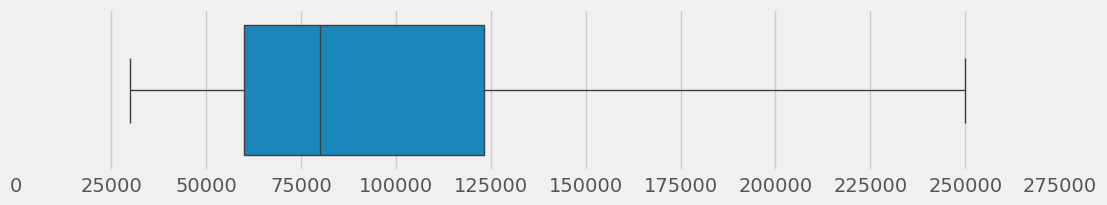

In [99]:
# just run this cell
plt.figure(figsize=(12, 2))
sns.boxplot(x=bachelor, whis=(0, 100))
plt.xticks(np.arange(0, 280000, 25000))
print("Boxplot of x values in mystery datasets")

---

## Question 4

Use NumPy functions or built-in Python functions to compute the five-number salary for `bachelor`, the salary distribution of Bachelor's degree recipients.

Recall that the five-number summary is:
* minimum
* first quartile (25th percentile)
* median (50th percentile)
* third quartile (75th percentile), and
* maximum.

In [91]:
bachelor_min = np.min(bachelor) # SOLUTION
bachelor_q1 = np.percentile(bachelor, 25) # SOLUTION
bachelor_median = np.median(bachelor) # SOLUTION
bachelor_q3 = np.percentile(bachelor, 75) # SOLUTION
bachelor_max = np.max(bachelor)

print("Five-number summary:")
print(f"min\t{bachelor_min}")
print(f"q1\t{bachelor_q1}")
print(f"median\t{bachelor_median}")
print(f"q3\t{bachelor_q3}")
print(f"max\t{bachelor_max}")

Five-number summary:
min	30000
q1	60000.0
median	80000.0
q3	123160.75
max	250000


**Verify**: Are these numbers reflected in the box plot above?

**Challenge**: Recompute the five-number summary above, but only using `np.percentile`.

---

# Question 5: Datasaurus: The limits of summary statistics

It can be easy to report summary statistics to quantify center and spread. However, these **summary statistics** do not tell the entire picture---literally! Let's explore an example involving four datasets that have very similar summary statistics but ultimately have very different distributions.

Consider the following `mystery` table, which contains the datapoints for four mystery datasets `slant_up`, `slant_down`, `bullseye`, and `dino`. Each of these datasets consists of (x, y) datapoints.

In [81]:
# just run this cell
mystery = Table.read_table("datasaurus.csv")
mystery = mystery.where("dataset", are.contained_in(["slant_up", "slant_down", "bullseye", "dino"]))
mystery

dataset,x,y
dino,55.3846,97.1795
dino,51.5385,96.0256
dino,46.1538,94.4872
dino,42.8205,91.4103
dino,40.7692,88.3333
dino,38.7179,84.8718
dino,35.641,79.8718
dino,33.0769,77.5641
dino,28.9744,74.4872
dino,26.1538,71.4103


## Question 5a

Complete the code below which finds how many datapoints are in each of the four datasets. The table `mystery_count` should have the form:

| dataset | count | 
| --- | --- |
| bullseye | ... | 
| dino | ... |
| slant_down | ... |
| slant_up | ... |

_Hint_: Review the previous lab and the Python Reference. What happens when we call `group` with one argument? with two arguments?

In [46]:
mystery_count = mystery.group("dataset") # SOLUTION
mystery_count

dataset,count
bullseye,142
dino,142
slant_down,142
slant_up,142


We can further use `group` to compute statistics on different columns. Run the below cell to examine the x- and y-means of datapoints, grouped by dataset:

In [82]:
# just run this cell
mystery_mean = mystery.group("dataset", np.mean)
mystery_mean

dataset,x mean,y mean
bullseye,54.2687,47.8308
dino,54.2633,47.8323
slant_down,54.2678,47.8359
slant_up,54.2659,47.8315


## Question 5b

* Students complete the code to compute `mystery_std` which computes the standard deviations by x and y for each of the four datasets

In [76]:
mystery_sd = mystery.group("dataset", np.std) # SOLUTION
mystery_sd

dataset,x std,y std
bullseye,16.7101,26.8407
dino,16.706,26.8404
slant_down,16.7076,26.8411
slant_up,16.7097,26.8436


## Question 5c

* same for `mystery_median`
* Hint: Maybe provide an additional `np.median` in the Python reference...

In [80]:
mystery_med = mystery.group("dataset", np.median) # SOLUTION
mystery_med

dataset,x median,y median
bullseye,53.8421,47.3829
dino,53.3333,46.0256
slant_down,53.1352,46.4013
slant_up,54.2613,45.2922


While the datasets have very similar means and standard deviations of x- and y-values, the median reveals that each dataset skews a bit differently. What's going on?

---

## Question 5d: Probably needs more scaffolding. See Lab 05 for wording.
Despite these summary statistics, we still have no way of understanding how the dataset distributions differ. To do so, we must visualize the distribution. To visualize two-dimensional distributions, we often use a scatter plot.

In the cell below, write code that produces a scatterplot of the `bullseye` datapoints.

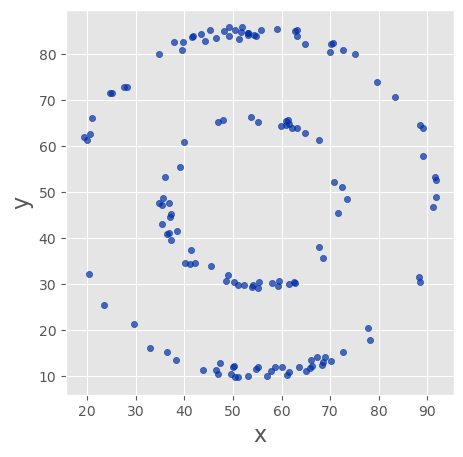

In [84]:
# BEGIN SOLUTION
bullseye = mystery.where("dataset", "bullseye")
bullseye.scatter("x", "y")
# END SOLUTION

### Bonus

The below code plots all four mystery datasets side-by-side. What do you notice? :-)

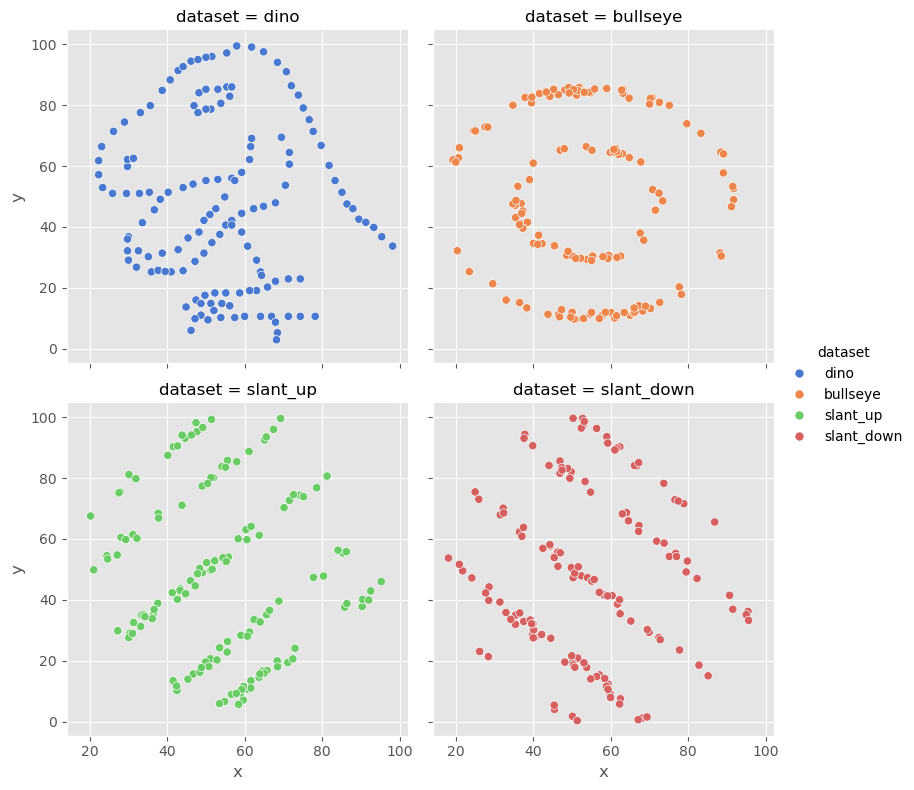

In [50]:
# just run this cell
sns.relplot(
    data=mystery, x="x", y="y", col="dataset", hue="dataset",
    col_wrap=2, palette="muted",
    height=4
)

---

## Done! 😇

---

## Pets of Data 6
Sunkist needs some head scratching before going to sleep. Can you help after submitting to Gradescope

<img src="sunkist.jpg" width="50%" alt="Two cute guinea pigs"/>